In [33]:
# Importing all the necessary libraries
import sys
!{sys.executable} -m pip install datasets
!{sys.executable} -m pip install torch torchvision



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
#importing the dataset from hugging face
from datasets import load_dataset

ds = load_dataset("ylecun/mnist")

#printout to make sure that it's loaded and happy
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


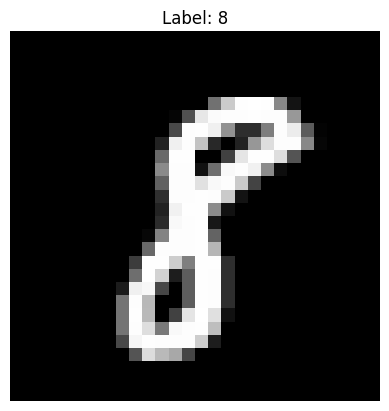

In [ ]:
import random
import matplotlib.pyplot as plt

#Printing random sample from the dataset to see if it works
sample = ds["train"][random.randrange(len(ds["train"]))]

plt.imshow(sample["image"], cmap="gray")
plt.title(f"Label: {sample['label']}")
plt.axis("off")
plt.show()

In [ ]:
#Converting data into a correct format, batch it and feed it to model 
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

#using the transform to convert the image to a tensor and normalize it
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

#defining the dataset class, wrapping in PyTorch format
class MNISTDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform 

    def __len__(self):
        return len(self.hf_dataset)

#extracting the image and label from the dataset
    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item["image"]
        label = item["label"]

#Applying tensor conversion and normalization if needed
        if self.transform:
            image = self.transform(image)

        return image, label

#defining the train and test datasets
train_dataset = MNISTDataset(ds["train"], transform=transform)
test_dataset = MNISTDataset(ds["test"], transform=transform)

#Creating data loaders that will group data in batches and feed it to model
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [ ]:
#defining the device to use for training (my computer doesn't have CUDA but doesn't hurt to see if the program will identify it correctly)
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
#Create neural network class: MLP (Multi-Layer Perceptron)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [39]:
def train(model, loader, epochs=3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

In [40]:
def test(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

In [41]:
mlp = MLP()
train(mlp, train_loader, epochs=3)
test(mlp, test_loader)

Epoch 1, Loss: 0.2567
Epoch 2, Loss: 0.1128
Epoch 3, Loss: 0.0771
Test Accuracy: 97.05%


97.05